In [18]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import binomtest, spearmanr, wilcoxon
import statsmodels.formula.api as smf
import xarray as xr

HERE = Path.cwd()
ANALYSIS_ROOT = HERE.parent
if str(ANALYSIS_ROOT) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT))

TILT_ROOT = Path("~/UNSW-MRes/MRes/seacofs_eddy_tilt_analysis").expanduser()
if str(TILT_ROOT) not in sys.path:
    sys.path.insert(0, str(TILT_ROOT))
import seacofs_tilt_tools as tilt

ESP_ROOT = Path("/home/z5297792/ESP_zonodo").expanduser()
if str(ESP_ROOT) not in sys.path:
    sys.path.insert(0, str(ESP_ROOT))
import functions as esp

sns.set_theme(style="ticks", context="notebook")
palette = {"AE": "#d95f02", "CE": "#1f78b4"}
exposure_order = ["planetary-dominated", "transitional/mixed", "topographic-dominated"]
exposure_palette = dict(zip(exposure_order, ["#4575b4", "#999999", "#d73027"]))

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, _ = tilt.load_tilt_tables(paths)
# df = mech.require_tilt_measurements(df)
# print(f"Rows: {len(df):,}; measured tilts: {df.TiltDis.notna().sum():,}; eddies: {df.Eddy.nunique():,}")

(np.float64(409.6625811519501),
 np.float64(541.6625811519501),
 np.float64(62.70755195367629),
 np.float64(194.70755195367627))

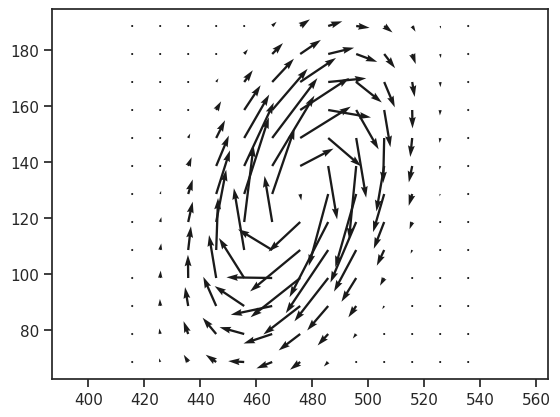

In [9]:
k = 0 
data = df_eddies.iloc[k]
gap = 2*data.Rc
res = 10
x, y = np.arange(data.xc-gap, data.xc+gap + res, res), np.arange(data.yc-gap, data.yc+gap + res, res)
X, Y = np.meshgrid(x,y)
uhat, vhat = esp.model_uv_at_xy(X, Y, data.xc, data.yc,
                            np.array([[data.q11, data.q12], [data.q12, data.q22]]),
                            data.Omega, data.Rc)
plt.quiver(X, Y, uhat, vhat)
plt.axis('equal')

In [10]:
df_vert = tilt.load_vert(paths, dic_form=False)

In [ ]:
df_eddy = df_vert[(df_vert.Eddy==data.Eddy)&(df_vert.Day==data.Day)].copy()
for z in len(df_eddy):
    z_data = df_eddy.iloc[z]


In [24]:
# Reconstruct velocity field using ESP parameters
U_all = []
V_all = []

df_eddy = df_vert[
    (df_vert.Eddy == data.Eddy) &
    (df_vert.Day == data.Day)
].copy()

for _, zdata in df_eddy.iterrows():

    Q = np.array([
        [zdata.q11, zdata.q12],
        [zdata.q12, zdata.q22]
    ])

    uhat, vhat = esp.model_uv_at_xy(
        X, Y,
        zdata.xc, zdata.yc,
        Q,
        zdata.Omega,
        zdata.Rc
    )

    U_all.append(uhat)
    V_all.append(vhat)

U_all = np.stack(U_all)   # (depth, y, x)
V_all = np.stack(V_all)


ds_model = xr.Dataset(
    data_vars={
        "u": (("depth", "y", "x"), U_all),
        "v": (("depth", "y", "x"), V_all),
    },
    coords={
        "depth": df_eddy["Depth"].values,   # change name if your depth column differs
        "x": np.arange(X.shape[1]),
        "y": np.arange(X.shape[0]),

        # physical coordinates
        "X": (("y", "x"), X),
        "Y": (("y", "x"), Y),
    },
)

ds_model

<xarray.Dataset> Size: 82kB
Dimensions:  (depth: 29, y: 13, x: 13)
Coordinates:
  * depth    (depth) float64 232B 0.0 5.88 10.73 ... 3.253e+03 3.93e+03 4.46e+03
  * x        (x) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * y        (y) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
    X        (y, x) float64 1kB 415.7 425.7 435.7 445.7 ... 515.7 525.7 535.7
    Y        (y, x) float64 1kB 68.71 68.71 68.71 68.71 ... 188.7 188.7 188.7
Data variables:
    u        (depth, y, x) float64 39kB -5.12e-07 -3.186e-06 ... 5.996e-06
    v        (depth, y, x) float64 39kB 3.067e-06 1.001e-05 ... -9.596e-06

do a series of plots showign the idealised (model) edd, also compare it in some plots to the original velcoity data in the netcdf files.